# Figure 1: Deconvolution Model

**Goal:**

Create the figures that will be used to convey the first result: Chromatin deconvolution increases temporal resolution.


In [6]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from src.Figure1_deconvolution import Figure1Deconvolution

fig1 = Figure1Deconvolution()

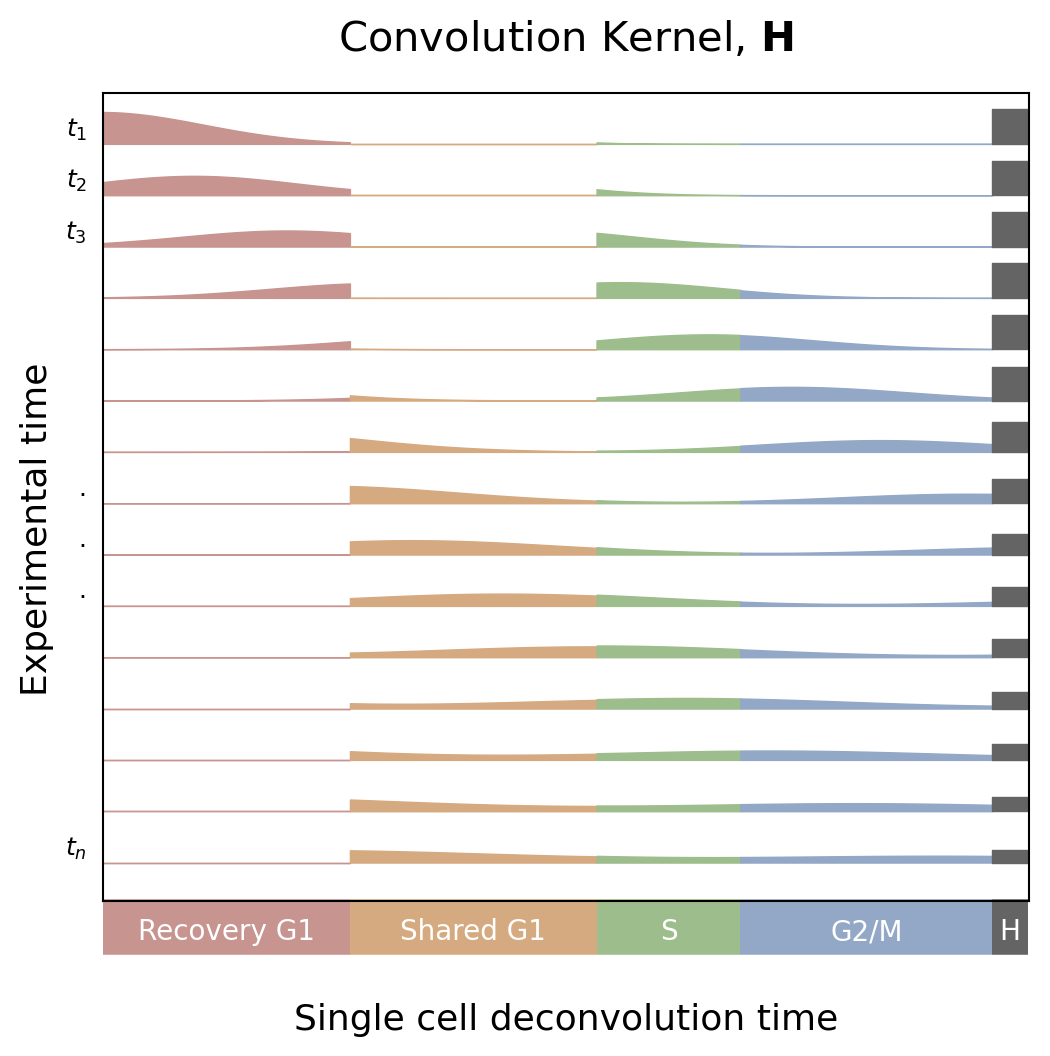

In [4]:
from src.figure_configs import save_figure_for_paper

fig1.plot_H_fill_betweens()
save_figure_for_paper("output/figures/Deconvolution_H_fill.png")

In [10]:
fig1.compute_clb2_deconvolution()

Applying copy number correction
Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Applying copy number correction
(16, 408) (16,)
Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.
Applying copy number correction
(15, 408) (15,)
Deconvolving combined model with gamma=0.006
Deconvolving bin size: 24x24
of G shape: (31, 408)
Deconvolving with gamma=0.006
0/408 - 00:00:00.095
100/408 - 00:00:07.063
200/408 - 00:00:13.890
300/408 - 00:00:20.813
400/408 - 00:00:27.351
Deconvolved in : 00:00:28.890
The fitting norm is 14.56, the smoothing norm is: 21.81


In [15]:
fig1.combined_model
# Create a plot that shows the MNase-seq data and the steps to convert it into
# a 2D image for deconvolution...


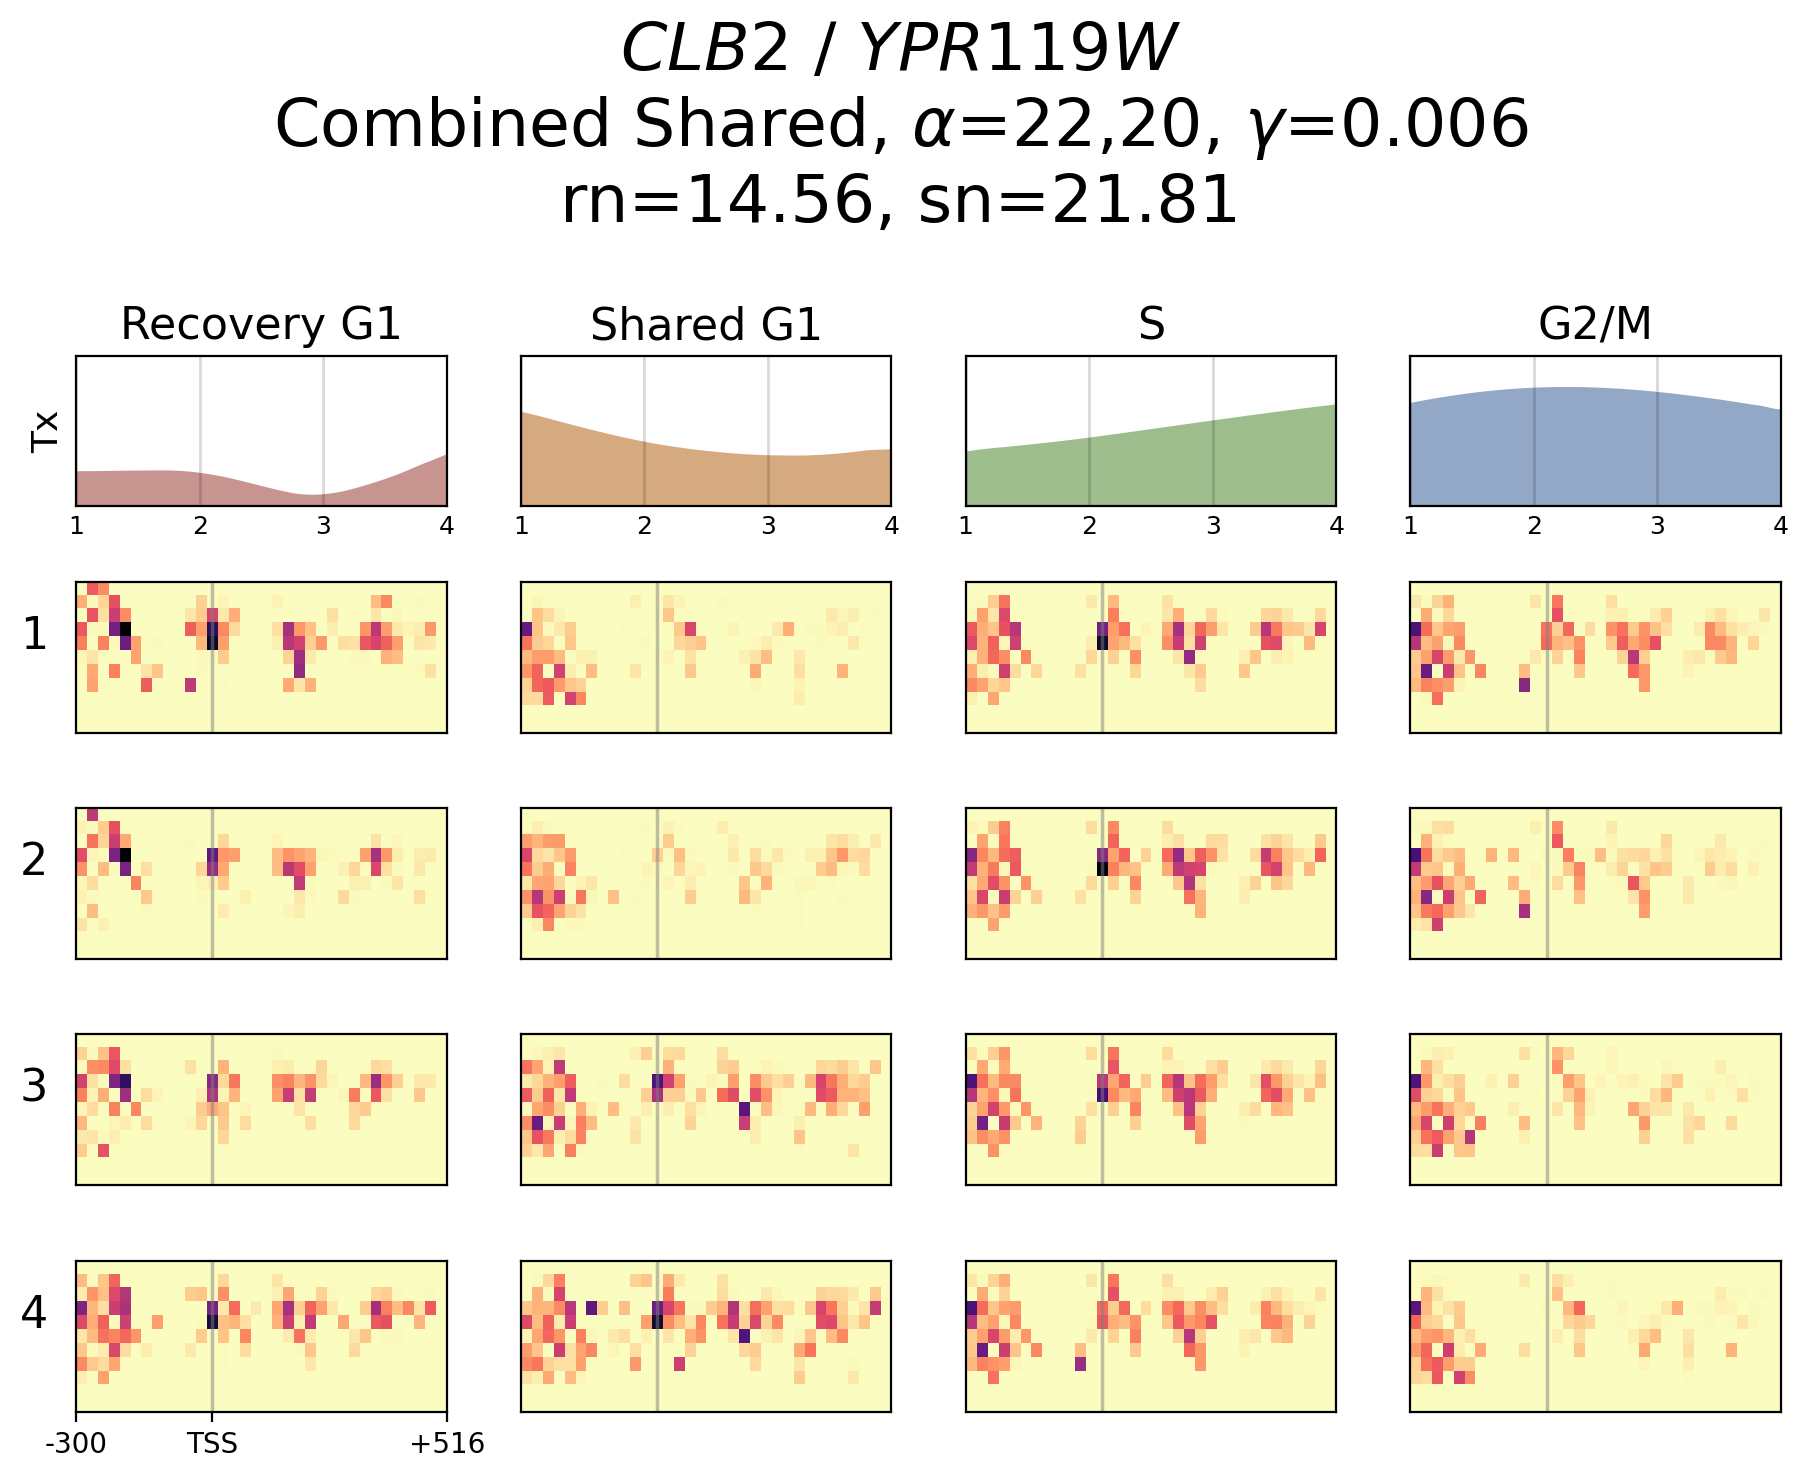

In [11]:
fig1.plot_clb2_deconvolution()
save_figure_for_paper('output/figures/Deconvolution_CLB2.png')

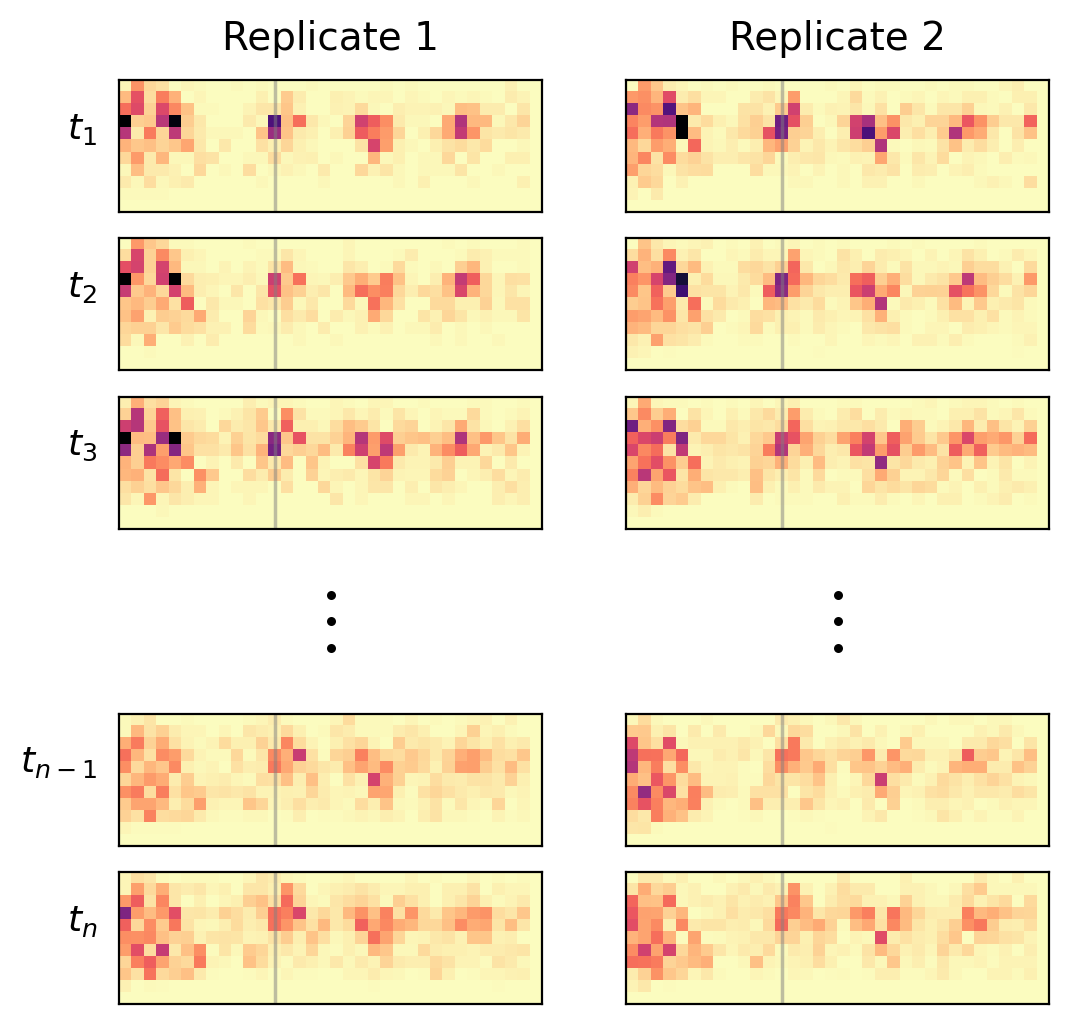

In [12]:
from src.figure_configs import save_figure_for_paper

fig1.plot_raw_clb2()
save_figure_for_paper('output/figures/Chromatin_Deconvolution/Deconvolution_raw.png')

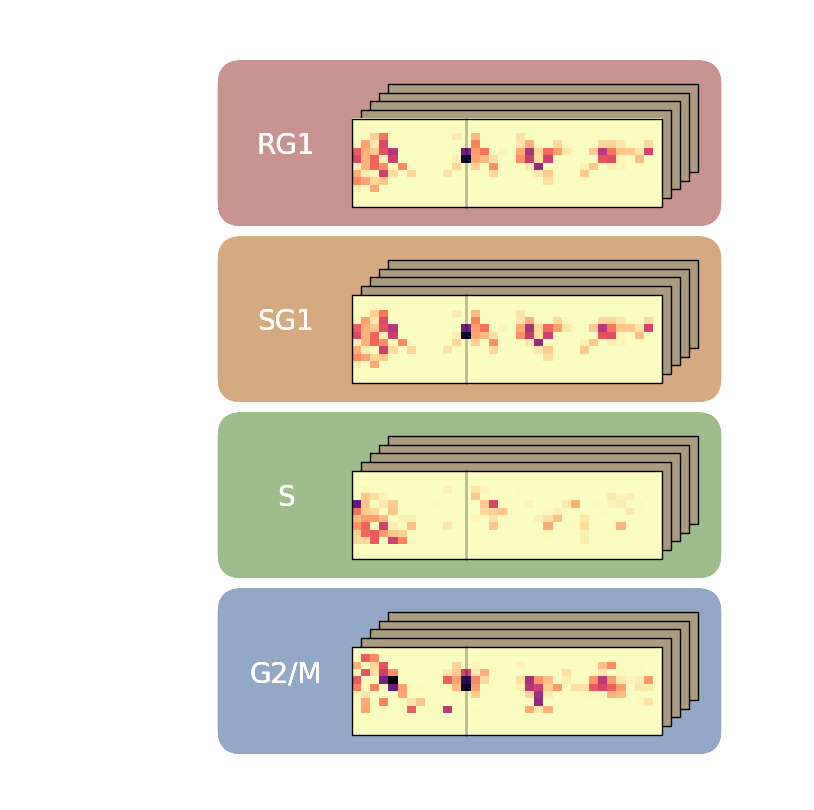

In [64]:
fig1.plot_deconvolved_clb2_phase_annotated()
save_figure_for_paper('output/figures/Chromatin_Deconvolution/Deconvolved_CLB2_phases.png')

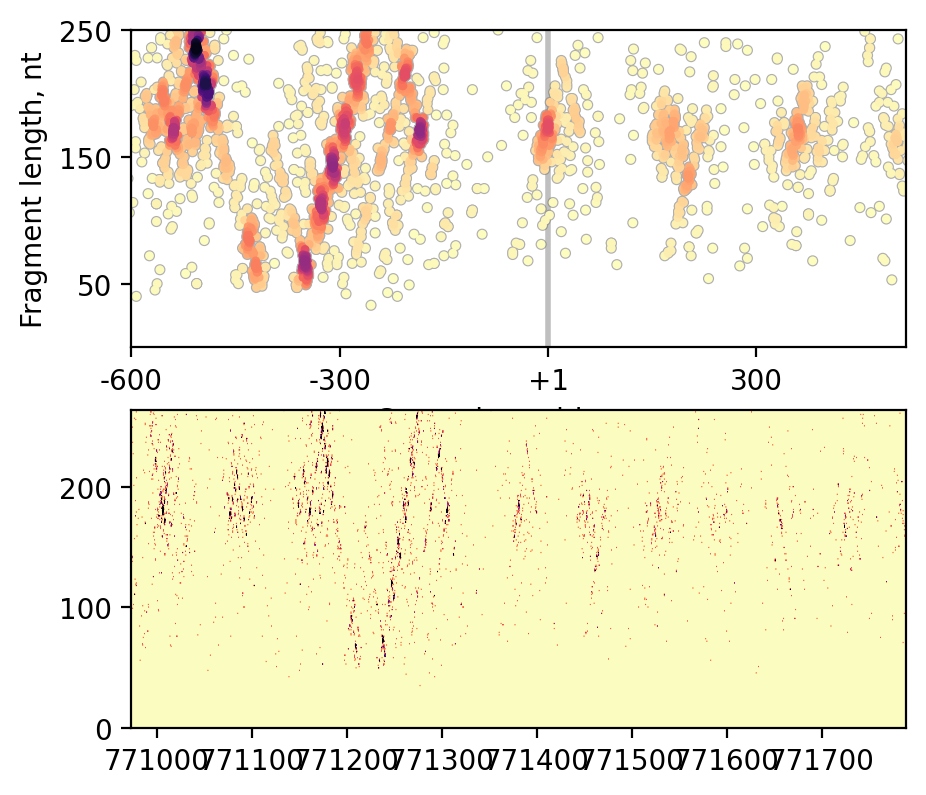

In [128]:
from src.DensityScatterPlotter import DensityScatterPlotter

chrom_model = fig1.combined_model.chrom1_model
reads = chrom_model.locus_reads
reads = reads[reads['sample'] == 0]
index = 0

plt.figure(figsize=(5, 7))
plt.subplot(3, 1, 1)

plt.axvline(chrom_model.computed_plus_one, c='gray', lw=2, alpha=0.5)

ax = plt.gca()
dsc_plotter = DensityScatterPlotter()
x, y = reads.mid, reads['length']

plt.scatter(x, y, s=9, edgecolors='#afafaf', facecolor='none')

dsc_plotter.set_data(x.values, y.values)
dsc_plotter.bw = (5, 10)
dsc_plotter.cmap = 'magma_r'
dsc_plotter.plot_ax(ax)
dsc_plotter.s = 7

ax.set_yticks(np.arange(50, 300, 100))
plt.ylim(0, 250)

xlims = chrom_model.bin_extents[0]-300, chrom_model.bin_extents[1]

p1 = chrom_model.computed_plus_one
xticks = np.arange(p1-900, p1+900, 300)
ax.set_xticks(xticks)
xtick_labels = ['+1' if x==p1 else str(x-p1) for x in xticks]
ax.set_xticklabels(xtick_labels)
plt.xlim(*xlims)
plt.xlabel("Genomic position, nt")
plt.ylabel("Fragment length, nt")

plt.subplot(3, 1, 2)
chrom_model.exact_bins.shape
plt.imshow(chrom_model.exact_bins[index], origin='lower', cmap='magma_r',
          aspect='auto', extent=chrom_model.bin_extents, vmax=1)